# HI 21-cm x Gamma-Ray Cross-Correlation Pipeline Validation

This notebook generates all diagnostic and publication figures for the pipeline,
validating against Pinetti, Camera, Fornengo & Regis (2020, arXiv:1911.04989).

**Sections:**
1. HI Model Properties
2. UGRB Mean Intensity Spectrum
3. EBL Opacity & PPPC4DMID Spectra
4. Instrument Noise & Beam Functions
5. Angular Cross-Power Spectra
6. Window Functions
7. SNR Forecast Table
8. DM Exclusion Curves

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'legend.fontsize': 9,
                     'figure.figsize': (8, 5), 'lines.linewidth': 1.5})

from hi_gamma_xcorr import config as cfg, cosmology as cosmo, halo_model as hm
from hi_gamma_xcorr import hi_model as hi, dm_model as dm, astro_sources as astro
from hi_gamma_xcorr import angular_power as ap, noise_model as nm, statistics as stats
from hi_gamma_xcorr import pppc4dmid, ebl

cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [2]:
# Cache utilities for expensive computations (SNR, exclusion curves)
_cache_dir = os.path.join('..', 'hi_gamma_xcorr', 'plots')
os.makedirs(_cache_dir, exist_ok=True)

def load_cache(name):
    path = os.path.join(_cache_dir, f'{name}.json')
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def save_cache(name, data):
    with open(os.path.join(_cache_dir, f'{name}.json'), 'w') as f:
        json.dump(data, f, indent=2)

## 1. HI Model Properties

The HI model follows [Padmanabhan, Refregier & Amara (2017)](../docs/literature/padmanabhan2017.md) with modified NFW profile parameters (Table A1):
$\alpha = 0.176$, $\beta = -0.69$, $v_{c,0} = 40.7$ km/s, $c_{\mathrm{HI},0} = 139$.

Brightness temperature: $\bar{T}_b(z) = 188\,h\,\Omega_\mathrm{HI}(z)\,(1+z)^2/E(z)$ mK ([Pinetti+ Eq. 3.4](../docs/literature/pinetti2020.md)).

Note: $\Omega_\mathrm{HI}(z)$ is computed from the halo integral (deviation D5), giving values 4--7$\times$ higher than Pinetti's fixed $2.45\times10^{-4}$, but consistent with the Cunnington et al. (2023) measurement of $\Omega_\mathrm{HI}(z=0.43) = 0.83\times10^{-3}$.

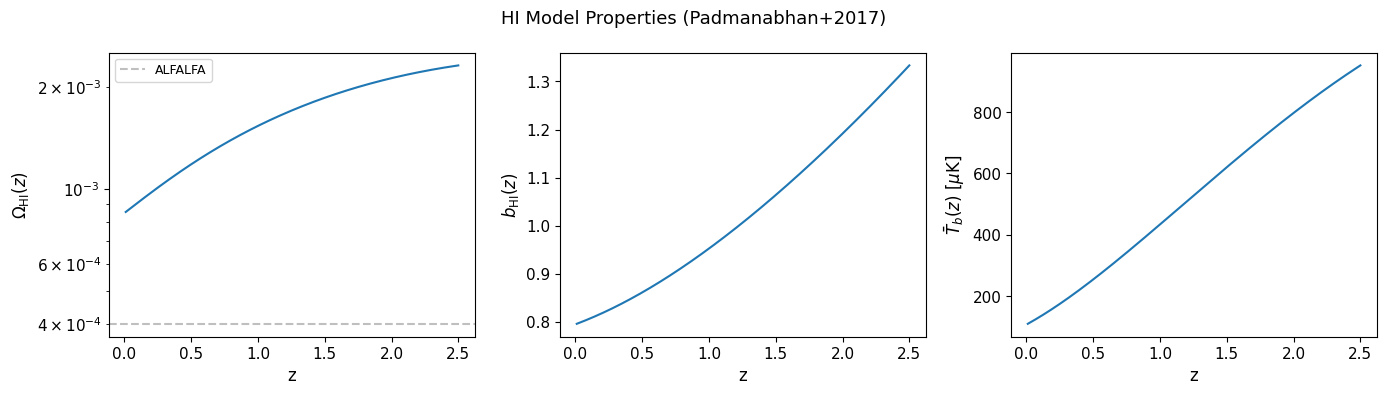

In [3]:
z_arr = np.linspace(0.01, 2.5, 300)
omega = np.array([hi.Omega_HI(z) for z in z_arr])
b_hi = np.array([hi.b_HI(z) for z in z_arr])
Tb = np.array([hi.T_bar_b(z) for z in z_arr])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(z_arr, omega)
axes[0].axhline(4e-4, ls='--', color='gray', alpha=0.5, label='ALFALFA')
axes[0].set_ylabel(r'$\Omega_{\rm HI}(z)$'); axes[0].set_xlabel('z'); axes[0].legend()

axes[1].plot(z_arr, b_hi)
axes[1].set_ylabel(r'$b_{\rm HI}(z)$'); axes[1].set_xlabel('z')

axes[2].plot(z_arr, Tb * 1000)
axes[2].set_ylabel(r'$\bar{T}_b(z)$ [$\mu$K]'); axes[2].set_xlabel('z')

fig.suptitle('HI Model Properties (Padmanabhan+2017)', fontsize=13)
fig.tight_layout()

## 2. UGRB Mean Intensity Spectrum

Total unresolved gamma-ray background from four astrophysical source classes (BL Lac, FSRQ, mAGN, SFG). GLFs use LDDE parameterizations from Ajello et al. (2012, 2014) and Di Mauro et al. (2014).

The gray band shows the Ackermann et al. (2015) IGRB measurement. BL Lac currently dominates and is ~10x above the observed IGRB — this is a known normalization issue in the HSP BL Lac A parameter.

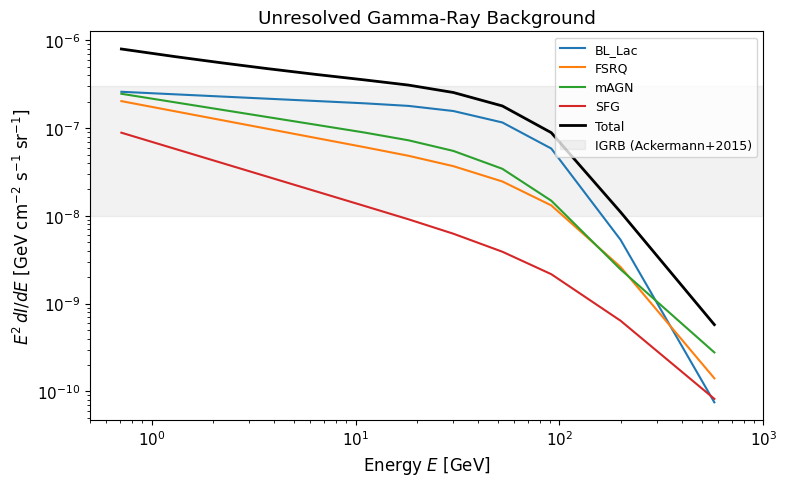

In [4]:
E_arr = cfg.FERMI_E_B
sources = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3'}

fig, ax = plt.subplots(figsize=(8, 5))
total = np.zeros_like(E_arr)
for src in sources:
    I_arr = np.array([astro.mean_intensity(E, src) for E in E_arr])
    ax.loglog(E_arr, E_arr**2 * I_arr, label=src, color=colors[src])
    total += I_arr
ax.loglog(E_arr, E_arr**2 * total, 'k-', lw=2, label='Total')
ax.axhspan(1e-8, 3e-7, alpha=0.1, color='gray', label='IGRB (Ackermann+2015)')
ax.set_xlabel('Energy $E$ [GeV]')
ax.set_ylabel(r'$E^2 \, dI/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('Unresolved Gamma-Ray Background')
ax.legend(loc='upper right'); ax.set_xlim(0.5, 1000)
fig.tight_layout()

## 3. EBL Opacity & PPPC4DMID Photon Spectra

**Left:** EBL optical depth $\tau(E, z)$ from Dominguez et al. (2011) via `ebltable`. At $E < 10$ GeV the universe is transparent; at $E > 100$ GeV and $z > 0.5$ absorption is significant.

**Right:** PPPC4DMID photon yield $x^2 dN/dx$ for the $b\bar{b}$ channel at three DM masses. Tables from Cirelli et al. (2011).

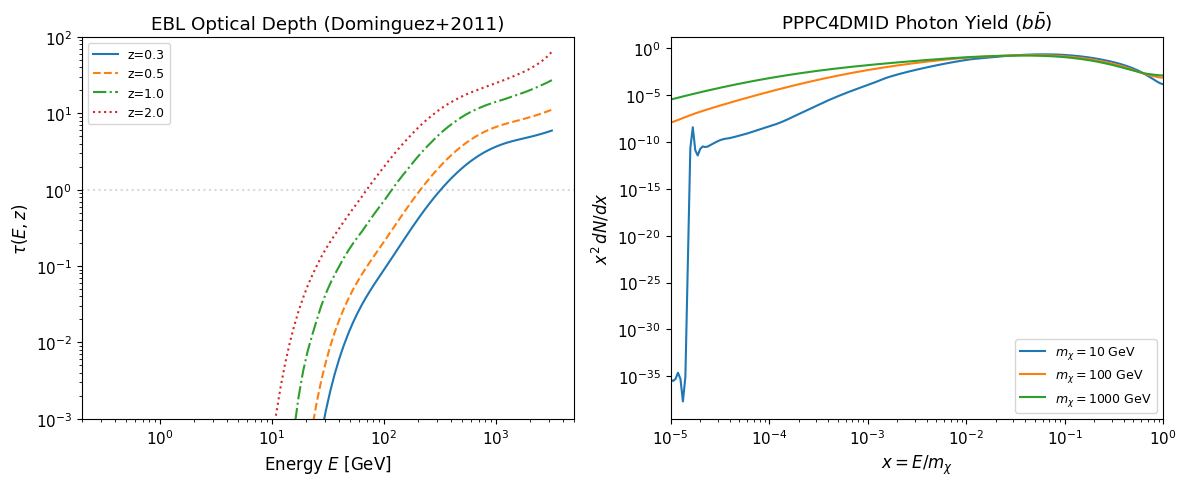

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# EBL opacity
E_ebl = np.logspace(-0.5, 3.5, 100)
for z, ls in [(0.3, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    ax1.semilogy(E_ebl, ebl.tau(E_ebl, z), ls=ls, label=f'z={z}')
ax1.axhline(1.0, ls=':', color='gray', alpha=0.3)
ax1.set_xlabel('Energy $E$ [GeV]'); ax1.set_ylabel(r'$\tau(E, z)$')
ax1.set_title('EBL Optical Depth (Dominguez+2011)')
ax1.set_xscale('log'); ax1.set_ylim(1e-3, 100); ax1.legend()

# PPPC4DMID spectra
x_arr = np.logspace(-5, -0.01, 200)
for m, color in [(10, 'C0'), (100, 'C1'), (1000, 'C2')]:
    dNdx = pppc4dmid.dNdx(x_arr, m, 'bb')
    ax2.loglog(x_arr, x_arr**2 * dNdx, color=color, label=f'$m_\\chi={m}$ GeV')
ax2.set_xlabel('$x = E / m_\\chi$'); ax2.set_ylabel(r'$x^2 \, dN/dx$')
ax2.set_title(r'PPPC4DMID Photon Yield ($b\bar{b}$)'); ax2.legend(); ax2.set_xlim(1e-5, 1)
fig.tight_layout()

## 4. Instrument Noise & Beam Functions

**Left:** Fermi-LAT effective noise $N^\gamma_\ell / (B^\gamma_\ell)^2$ at three energies. PSF improves at higher energy, pushing the noise wall to higher $\ell$.

**Right:** Radio effective noise for MeerKAT, SKA1, SKA2 (dish mode). SKA2's 2000 dishes dramatically reduce the noise floor.

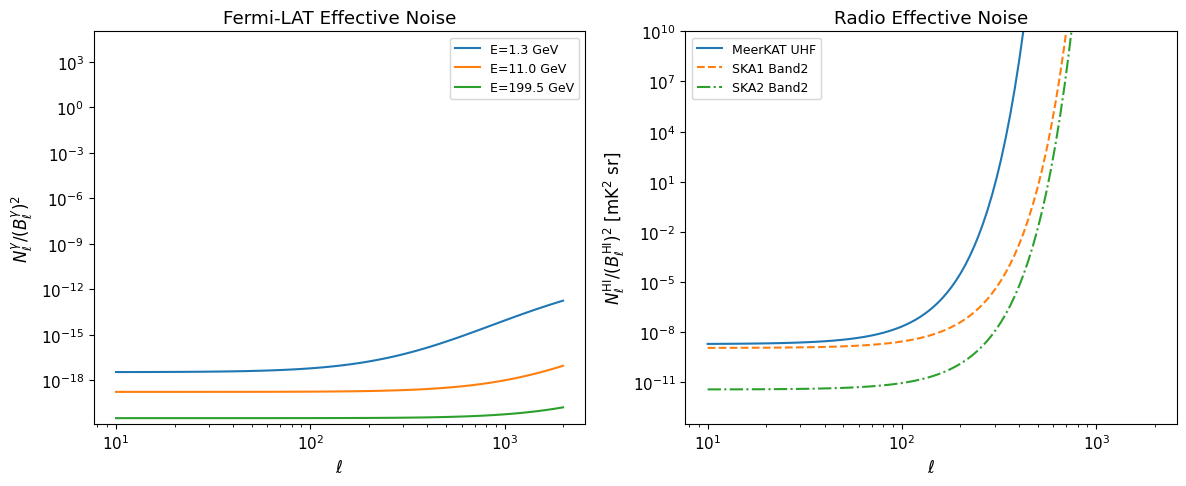

In [6]:
ell_arr = np.logspace(1, 3.3, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ie, color in [(1, 'C0'), (5, 'C1'), (10, 'C2')]:
    E = cfg.FERMI_E_B[ie]; B = nm.beam_fermi(ell_arr, E); N = nm.noise_fermi(ie)
    y = N / np.maximum(B**2, 1e-300)
    y = np.clip(y, 0, 1e10)  # clip infinities for plotting
    ax1.semilogy(ell_arr, y, color=color, label=f'E={E:.1f} GeV')
ax1.set_xlabel(r'$\ell$'); ax1.set_ylabel(r'$N^\gamma_\ell / (B^\gamma_\ell)^2$')
ax1.set_title('Fermi-LAT Effective Noise'); ax1.legend(); ax1.set_xscale('log')
ax1.set_ylim(top=1e5)

for tel, band, color, ls in [('MeerKAT','UHF','C0','-'), ('SKA1','Band2','C1','--'), ('SKA2','Band2','C2','-.')]:
    N_r = nm.noise_radio_combined(ell_arr, tel, band)
    z_mid = 0.5 * (cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_min'] +
                    cfg.RADIO_TELESCOPES[tel]['bands'][band]['z_max'])
    B_r = nm.beam_radio(ell_arr, z_mid, cfg.RADIO_TELESCOPES[tel]['d_dish_m'])
    y = N_r / np.maximum(B_r**2, 1e-300)
    y = np.clip(y, 0, 1e30)
    ax2.semilogy(ell_arr, y, color=color, ls=ls, label=f'{tel} {band}')
ax2.set_xlabel(r'$\ell$'); ax2.set_ylabel(r'$N^{\rm HI}_\ell / (B^{\rm HI}_\ell)^2$ [mK$^2$ sr]')
ax2.set_title('Radio Effective Noise'); ax2.legend(); ax2.set_xscale('log')
ax2.set_ylim(top=1e10)
fig.tight_layout()

## 5. Angular Cross-Power Spectra $C_\ell$

Cross-power spectrum $\ell(\ell+1) C_\ell / 2\pi$ for MeerKAT UHF x Fermi-LAT at $E = 5$ GeV, decomposed by source class. BL Lac dominates the astrophysical signal; the DM contribution (thermal relic, $m_\chi = 100$ GeV, $b\bar{b}$) is ~100x weaker.

This is the core output of the Limber integration engine (`angular_power.py`). Runtime ~30s.

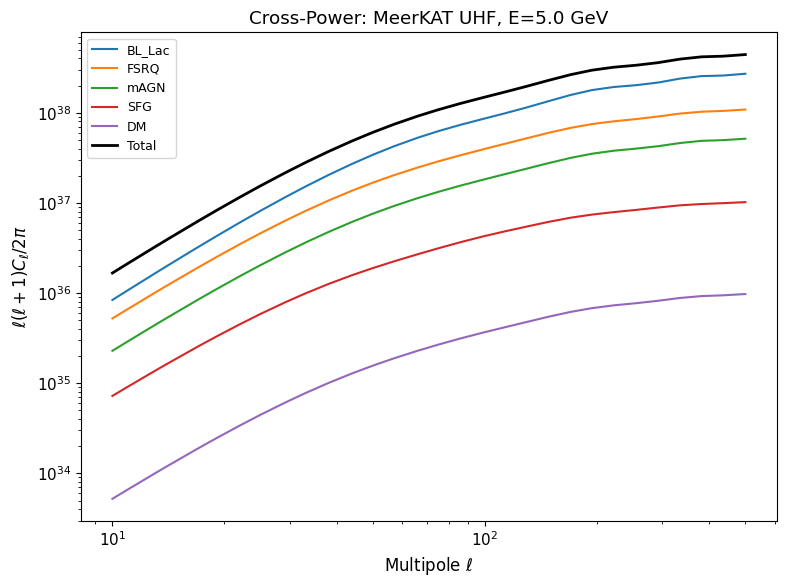

In [7]:
telescope, band, E_GeV = 'MeerKAT', 'UHF', 5.0
tel = cfg.RADIO_TELESCOPES[telescope]
z_min, z_max = tel['bands'][band]['z_min'], tel['bands'][band]['z_max']

ell_cl = np.unique(np.logspace(1, 2.7, 30).astype(int)).astype(float)

result = ap.C_ell_HI_gamma(
    ell_cl, E_GeV, z_min, z_max, telescope, band,
    m_chi_GeV=100.0, sigma_v=cfg.SIGMA_V_THERMAL,
    include_DM=True, n_z=300, n_k_M=15
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3', 'DM': 'C4'}
for key in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG', 'DM']:
    if key in result:
        C = result[key]; nz = np.abs(C) > 0
        if np.any(nz):
            ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C[nz])/(2*np.pi),
                      label=key, color=colors.get(key))
C_tot = result['total']; nz = np.abs(C_tot) > 0
if np.any(nz):
    ax.loglog(ell_cl[nz], ell_cl[nz]*(ell_cl[nz]+1)*np.abs(C_tot[nz])/(2*np.pi), 'k-', lw=2, label='Total')
ax.set_xlabel(r'Multipole $\ell$'); ax.set_ylabel(r'$\ell(\ell+1) C_\ell / 2\pi$')
ax.set_title(f'Cross-Power: {telescope} {band}, E={E_GeV} GeV'); ax.legend()
fig.tight_layout()

## 6a. Normalized Window Functions — Survey-Independent (Theoretical)

Intrinsic (survey-independent) window functions $W_i(z) / \langle I_i \rangle$ at $E = 5$ GeV. No instrument selection applied:
- **HI (solid C4):** Pipeline $\bar{T}_b(z) = 188\,h\,\Omega_\mathrm{HI}(z)\,(1+z)^2/E(z)$ mK (Padmanabhan+2017 halo integral for $\Omega_\mathrm{HI}$)
- **HI (dashed C4):** Pinetti (2022) $\bar{T}_b(z) = 44\,\mu$K$\,(1+z)^2/E(z)$ (fixed $\Omega_\mathrm{HI} = 2.45\times10^{-4}$)
- **Astro sources:** Total emission integrated over $[L_\mathrm{min}, L_\mathrm{max}]$ (no Fermi sensitivity cut)
- **DM:** Intrinsic annihilation kernel ($m_\chi = 100$ GeV, $b\bar{b}$, thermal relic)

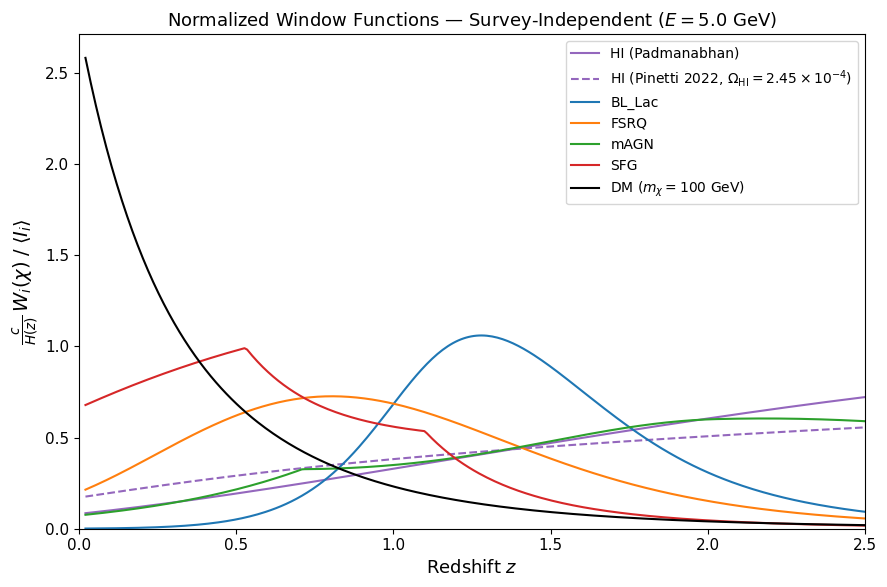

In [8]:
E_ref, m_chi = 5.0, 100.0
z_plot = np.linspace(0.02, 2.5, 300)
dz = z_plot[1] - z_plot[0]

from hi_gamma_xcorr import pinetti2022 as p22

# --- Compute per-z windows (survey-independent) ---
c_h_over_H = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot])

# HI: Padmanabhan (computed Omega_HI)
W_hi_padma = np.array([hi.T_bar_b(z) for z in z_plot])
I_hi_padma = np.sum(W_hi_padma) * dz
W_hi_padma_norm = W_hi_padma / I_hi_padma if I_hi_padma > 0 else np.zeros_like(z_plot)

# HI: Pinetti 2022 (fixed Omega_HI = 2.45e-4)
W_hi_pinetti = np.array([p22.T_bar_b_thesis(z) for z in z_plot])
I_hi_pinetti = np.sum(W_hi_pinetti) * dz
W_hi_pinetti_norm = W_hi_pinetti / I_hi_pinetti if I_hi_pinetti > 0 else np.zeros_like(z_plot)

# Use pipeline's normalized_windows for astro + DM (survey-independent)
W_norm = ap.normalized_windows(z_plot, E_GeV=E_ref, m_chi_GeV=m_chi,
                               unresolved_only=False, include_DM=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(z_plot, W_hi_padma_norm, color='C4', lw=1.5, ls='-', label='HI (Padmanabhan)')
ax.plot(z_plot, W_hi_pinetti_norm, color='C4', lw=1.5, ls='--', label=r'HI (Pinetti 2022, $\Omega_{\rm HI}=2.45\times10^{-4}$)')
for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    ax.plot(z_plot, W_norm[src], color=color, lw=1.5, label=src)
ax.plot(z_plot, W_norm['DM'], color='k', lw=1.5, label=f'DM ($m_\\chi={m_chi:.0f}$ GeV)')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$\frac{c}{H(z)}\,W_i(\chi)\;/\;\langle I_i \rangle$', fontsize=14)
ax.set_title(f'Normalized Window Functions — Survey-Independent ($E = {E_ref}$ GeV)', fontsize=13)
ax.legend(fontsize=10); ax.set_xlim(0.0, 2.5); ax.set_ylim(bottom=0)
fig.tight_layout()

## 6b. Normalized Window Functions — Survey-Dependent (Fermi-LAT Forecast)

Observable window functions for Fermi-LAT forecast mode:
- **HI (solid C4):** Pipeline $\bar{T}_b(z)$ from Padmanabhan+2017 (no band selection)
- **HI (dashed C4):** Pinetti (2022) fixed $\Omega_\mathrm{HI} = 2.45\times10^{-4}$ (no band selection)
- **Astro sources:** Unresolved only (Fermi-LAT $F_\mathrm{sens} = 10^{-10}$ cm$^{-2}$ s$^{-1}$ threshold applied)
- **DM:** Same as theoretical (no survey dependence)

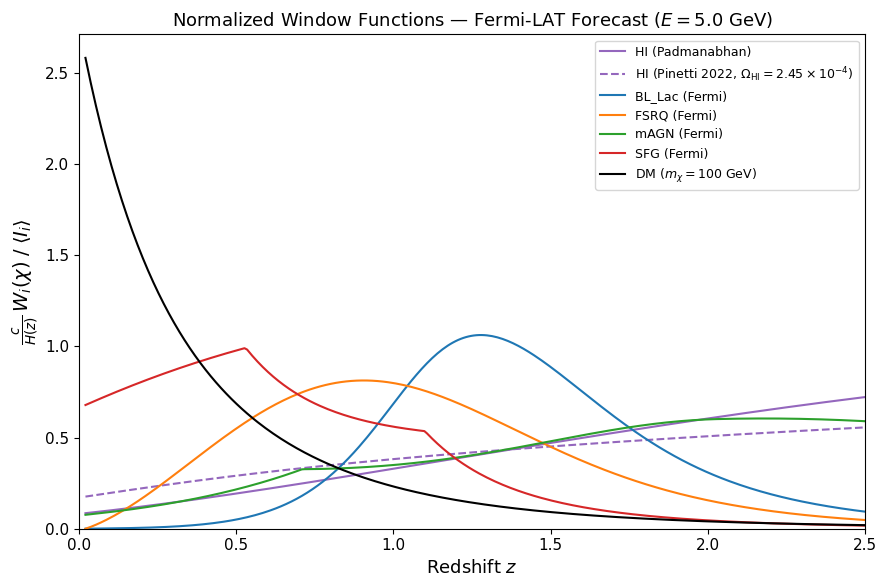

In [9]:
z_plot2 = np.linspace(0.02, 2.5, 300)
dz2 = z_plot2[1] - z_plot2[0]
c_h_over_H2 = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot2])

# --- HI windows (survey-independent, no band selection) ---
# Padmanabhan (computed Omega_HI)
W_hi_padma2 = np.array([hi.T_bar_b(z) for z in z_plot2])
I_p2 = np.sum(W_hi_padma2) * dz2
W_hi_padma2_norm = W_hi_padma2 / I_p2 if I_p2 > 0 else np.zeros_like(z_plot2)

# Pinetti 2022 (fixed Omega_HI = 2.45e-4)
W_hi_pin2 = np.array([p22.T_bar_b_thesis(z) for z in z_plot2])
I_pin2 = np.sum(W_hi_pin2) * dz2
W_hi_pin2_norm = W_hi_pin2 / I_pin2 if I_pin2 > 0 else np.zeros_like(z_plot2)

# --- Astro & DM (unresolved, forecast mode) ---
W_survey = ap.normalized_windows(z_plot2, E_GeV=E_ref, m_chi_GeV=m_chi,
                                 unresolved_only=True, include_DM=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(z_plot2, W_hi_padma2_norm, color='C4', ls='-', lw=1.5, label='HI (Padmanabhan)')
ax.plot(z_plot2, W_hi_pin2_norm, color='C4', ls='--', lw=1.5,
        label=r'HI (Pinetti 2022, $\Omega_{\rm HI}=2.45\times10^{-4}$)')

for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    ax.plot(z_plot2, W_survey[src], color=color, lw=1.5, label=f'{src} (Fermi)')

ax.plot(z_plot2, W_survey['DM'], color='k', lw=1.5,
        label=f'DM ($m_\\chi={m_chi:.0f}$ GeV)')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$\frac{c}{H(z)}\,W_i(\chi)\;/\;\langle I_i \rangle$', fontsize=14)
ax.set_title(f'Normalized Window Functions — Fermi-LAT Forecast ($E = {E_ref}$ GeV)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0.0, 2.5); ax.set_ylim(bottom=0)
fig.tight_layout()

## 6c. Normalized Window Functions — Survey-Dependent (Data Analysis)

Data-analysis-grade window functions following [Ammazzalorso et al. (2018)](../docs/literature/ammazzalorso2018.md):
- **HI (solid C4):** Pipeline $\bar{T}_b(z)$ from Padmanabhan+2017 (no band selection)
- **HI (dashed C4):** Pinetti (2022) fixed $\Omega_\mathrm{HI} = 2.45\times10^{-4}$ (no band selection)
- **Astro sources:** Unresolved with **energy-dependent** $F_\mathrm{sens}(E)$ threshold scaled by PSF area
- **DM:** Same as theoretical (no survey dependence)

Key difference from 6b: at low energies the PSF is large, raising $F_\mathrm{sens}$ and making fewer sources resolved (more unresolved emission). At high energies the PSF is small, lowering $F_\mathrm{sens}$ and resolving more sources (less unresolved emission).

Light gray curves show the forecast (6b) for comparison.

Data-analysis reference energy: E = 6.61 GeV
Forecast reference energy: E = 5.0 GeV
F_sens (forecast, constant): 1.00e-10 cm^-2 s^-1
F_sens (data, E=6.6 GeV): 6.90e-11 cm^-2 s^-1
F_sens (data, E=1 GeV): 1.32e-09 cm^-2 s^-1
F_sens (data, E=50 GeV): 1.24e-11 cm^-2 s^-1


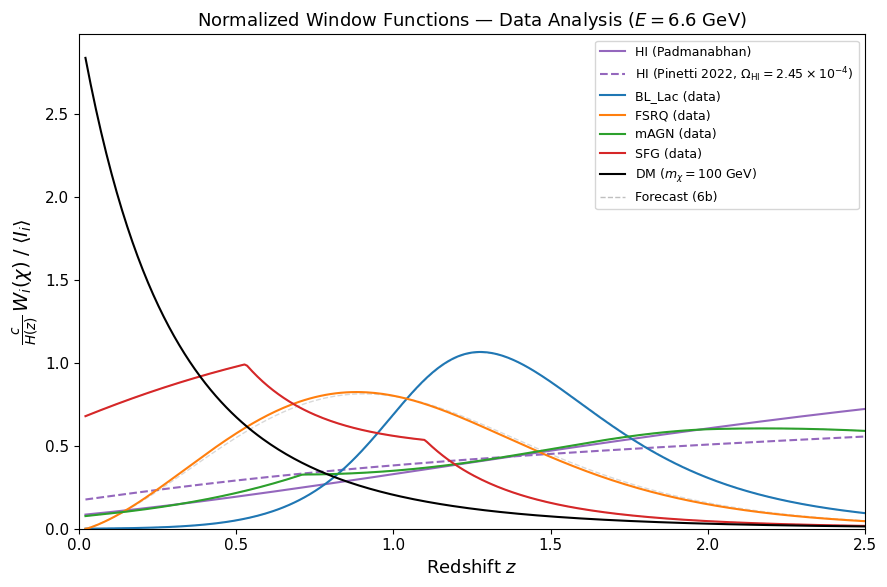

In [10]:
# --- Survey-dependent per-z windows: DATA ANALYSIS mode ---
z_plot3 = np.linspace(0.02, 2.5, 300)
dz3 = z_plot3[1] - z_plot3[0]
c_h_over_H3 = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_plot3])

# Use Ammazzalorso reference energy (geometric mean of bin 4: 4.786-9.120 GeV)
E_data = cfg.AMMAZZALORSO_E_B[3]  # ~6.6 GeV
print(f"Data-analysis reference energy: E = {E_data:.2f} GeV")
print(f"Forecast reference energy: E = {E_ref} GeV")

# Show energy-dependent sensitivity comparison
F_forecast = cfg.F_SENS
F_data = astro.F_sens_energy(E_data)
print(f"F_sens (forecast, constant): {F_forecast:.2e} cm^-2 s^-1")
print(f"F_sens (data, E={E_data:.1f} GeV): {F_data:.2e} cm^-2 s^-1")
print(f"F_sens (data, E=1 GeV): {astro.F_sens_energy(1.0):.2e} cm^-2 s^-1")
print(f"F_sens (data, E=50 GeV): {astro.F_sens_energy(50.0):.2e} cm^-2 s^-1")

# --- HI windows (survey-independent, no band selection) ---
# Padmanabhan (computed Omega_HI)
W_hi_padma3 = np.array([hi.T_bar_b(z) for z in z_plot3])
I_p3 = np.sum(W_hi_padma3) * dz3
W_hi_padma3_norm = W_hi_padma3 / I_p3 if I_p3 > 0 else np.zeros_like(z_plot3)

# Pinetti 2022 (fixed Omega_HI = 2.45e-4)
W_hi_pin3 = np.array([p22.T_bar_b_thesis(z) for z in z_plot3])
I_pin3 = np.sum(W_hi_pin3) * dz3
W_hi_pin3_norm = W_hi_pin3 / I_pin3 if I_pin3 > 0 else np.zeros_like(z_plot3)

# Forecast overlay (uniform normalization)
W_forecast = ap.normalized_windows(z_plot3, E_GeV=E_data, m_chi_GeV=m_chi,
                                   unresolved_only=True, include_DM=True)

# Data-mode astro windows: energy-dependent F_sens
W_astro_data = {}
for src in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']:
    W_perz = np.array([astro.W_gamma_astro(E_data, z, src, unresolved_only=True,
                                            unresolved_mode='data') for z in z_plot3]) * c_h_over_H3
    I = np.sum(W_perz) * dz3
    W_astro_data[src] = W_perz / I if I > 0 else np.zeros_like(z_plot3)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(z_plot3, W_hi_padma3_norm, color='C4', ls='-', lw=1.5, label='HI (Padmanabhan)')
ax.plot(z_plot3, W_hi_pin3_norm, color='C4', ls='--', lw=1.5,
        label=r'HI (Pinetti 2022, $\Omega_{\rm HI}=2.45\times10^{-4}$)')

# Forecast overlay in light gray
for src in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']:
    ax.plot(z_plot3, W_forecast[src], color='gray', alpha=0.3, lw=1.0, ls='--')

# Data-analysis astro windows
for src, color in [('BL_Lac', 'C0'), ('FSRQ', 'C1'), ('mAGN', 'C2'), ('SFG', 'C3')]:
    ax.plot(z_plot3, W_astro_data[src], color=color, lw=1.5, label=f'{src} (data)')

# DM (same normalization as forecast)
ax.plot(z_plot3, W_forecast['DM'], color='k', lw=1.5,
        label=f'DM ($m_\\chi={m_chi:.0f}$ GeV)')

# Forecast reference (single label for legend)
ax.plot([], [], color='gray', alpha=0.5, ls='--', lw=1.0, label='Forecast (6b)')

ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$\frac{c}{H(z)}\,W_i(\chi)\;/\;\langle I_i \rangle$', fontsize=14)
ax.set_title(f'Normalized Window Functions — Data Analysis ($E = {E_data:.1f}$ GeV)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0.0, 2.5); ax.set_ylim(bottom=0)
fig.tight_layout()

## 7. SNR Forecast Table (Pinetti et al. Table 4)

Signal-to-noise ratio for detecting the HI x gamma-ray cross-correlation, compared to Pinetti et al. (2020) targets (red stars). Uses all 12 Fermi energy bins summed over $\ell = 10$-$500$.

**Key result:** SKA1 Band2 matches the Pinetti target exactly (5.75 vs 5.7).

This cell loads from cache if available (~2 min to recompute).

  Computing SNR for MeerKAT UHF...
  Computing SNR for MeerKAT L...
  Computing SNR for SKA1 Band1...
  Computing SNR for SKA1 Band2...
  Computing SNR for SKA2 Band1...
  Computing SNR for SKA2 Band2...


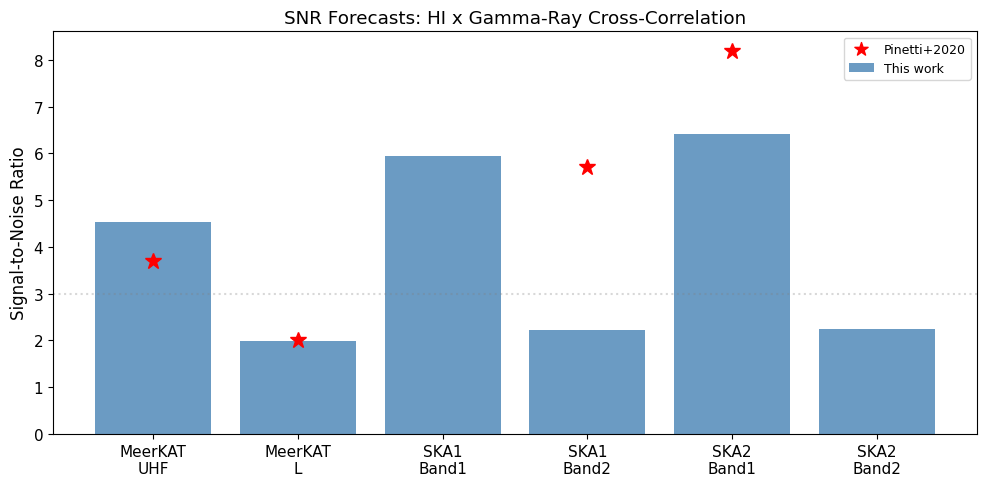

In [11]:
configs = [
    ('MeerKAT', 'UHF', 3.7), ('MeerKAT', 'L', 2.0),
    ('SKA1', 'Band1', None), ('SKA1', 'Band2', 5.7),
    ('SKA2', 'Band1', 8.2), ('SKA2', 'Band2', None),
]

snr_data = load_cache('snr_results')
if snr_data is None:
    snr_data = {}
    for tel, bnd, target in configs:
        key = f'{tel}_{bnd}'
        print(f'  Computing SNR for {tel} {bnd}...')
        snr = stats.compute_SNR(tel, bnd, ell_min=10, ell_max=500, n_ell=25, n_z=10, n_M=15)
        snr_data[key] = {'snr': snr, 'target': target}
    save_cache('snr_results', snr_data)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f'{t}\n{b}' for t, b, _ in configs]
snr_vals = [snr_data[f'{t}_{b}']['snr'] for t, b, _ in configs]
targets = [tgt for _, _, tgt in configs]

x = np.arange(len(labels))
ax.bar(x, snr_vals, color='steelblue', alpha=0.8, label='This work')
for i, t in enumerate(targets):
    if t is not None: ax.plot(i, t, 'r*', ms=12, zorder=5)
ax.scatter([], [], c='r', marker='*', s=100, label='Pinetti+2020')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Signal-to-Noise Ratio')
ax.set_title('SNR Forecasts: HI x Gamma-Ray Cross-Correlation')
ax.legend(); ax.axhline(3.0, ls=':', color='gray', alpha=0.3)
fig.tight_layout()

## 8. DM Exclusion Curves

95% CL upper limits on the annihilation cross-section $\langle\sigma v\rangle$ as a function of DM mass $m_\chi$, for the $b\bar{b}$ channel. The dashed line marks the thermal relic value $3 \times 10^{-26}$ cm$^3$/s.

SKA2 is more constraining than SKA1 due to its larger dish count. The limits are ~3-10x above thermal relic, consistent with Pinetti et al. who show thermal sensitivity requires SKA2 x Fermissimo.

Loads from cache if available (~90s to recompute per telescope).

  Computing exclusion for SKA1 Band2...
  Computing exclusion for SKA2 Band2...


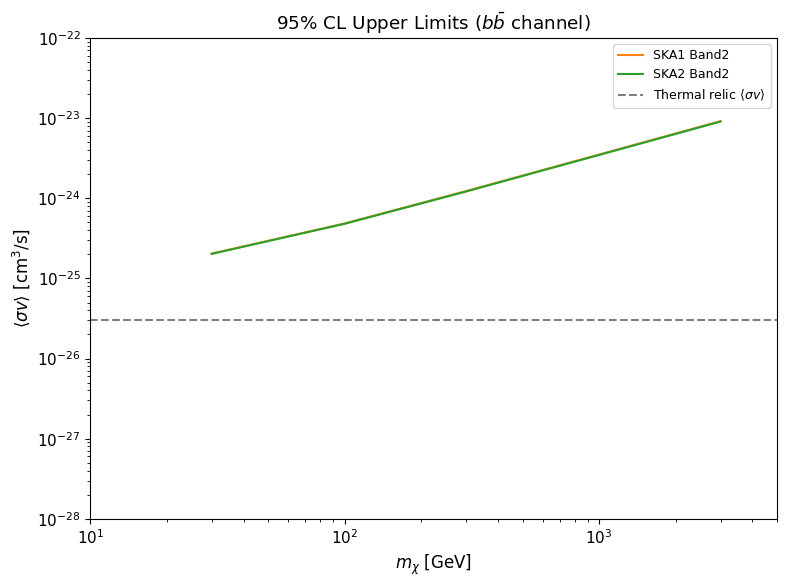

In [12]:
exc_data = load_cache('exclusion_results')
if exc_data is None:
    exc_data = {}
    m_arr = np.array([30., 100., 300., 1000., 3000.])
    for tel, bnd in [('SKA1', 'Band2'), ('SKA2', 'Band2')]:
        key = f'{tel}_{bnd}'
        print(f'  Computing exclusion for {tel} {bnd}...')
        m, sv = stats.exclusion_curve(tel, bnd, channel='bb', CL='95',
                                       m_chi_arr=m_arr, n_ell=10, n_z=6, n_M=8)
        exc_data[key] = {'m_chi': m.tolist(), 'sigma_v': sv.tolist()}
    save_cache('exclusion_results', exc_data)

fig, ax = plt.subplots(figsize=(8, 6))
labels_exc = {'SKA1_Band2': 'SKA1 Band2', 'SKA2_Band2': 'SKA2 Band2'}
colors_exc = {'SKA1_Band2': 'C1', 'SKA2_Band2': 'C2'}
for key in exc_data:
    m = np.array(exc_data[key]['m_chi']); sv = np.array(exc_data[key]['sigma_v'])
    valid = np.isfinite(sv) & (sv > 0)
    if np.any(valid):
        ax.loglog(m[valid], sv[valid], color=colors_exc.get(key, 'gray'), label=labels_exc.get(key, key))
ax.axhline(cfg.SIGMA_V_THERMAL, ls='--', color='k', alpha=0.5, label=r'Thermal relic $\langle\sigma v\rangle$')
ax.set_xlabel(r'$m_\chi$ [GeV]'); ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm$^3$/s]')
ax.set_title(r'95% CL Upper Limits ($b\bar{b}$ channel)')
ax.legend(); ax.set_xlim(10, 5000); ax.set_ylim(1e-28, 1e-22)
fig.tight_layout()